In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv('../Data/deliveries.csv')

In [13]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [14]:
df.shape

(260920, 17)

In [15]:
df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Data Cleaning

In [16]:
# Check for missing values and data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Unique values in key columns:")
print(f"Unique match_ids: {df['match_id'].nunique()}")
print(f"Unique batting teams: {df['batting_team'].nunique()}")
print(f"Unique bowling teams: {df['bowling_team'].nunique()}")

Data Types:
match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object

Missing Values:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Unique values in key columns:
Unique match

In [17]:
# Replace 'NA' strings with actual NaN values
df = df.replace('NA', np.nan)
df = df.replace('', np.nan)

print("After replacing 'NA' strings:")
print(df.isnull().sum())

After replacing 'NA' strings:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [18]:
# Convert data types to appropriate formats
df['match_id'] = df['match_id'].astype('int64')
df['inning'] = df['inning'].astype('int64')
df['over'] = df['over'].astype('int64')
df['ball'] = df['ball'].astype('int64')
df['batsman_runs'] = df['batsman_runs'].astype('int64')
df['extra_runs'] = df['extra_runs'].astype('int64')
df['total_runs'] = df['total_runs'].astype('int64')
df['is_wicket'] = df['is_wicket'].astype('int64')

print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object


In [19]:
# Check for duplicates
print("Duplicate rows:")
duplicate_count = df.duplicated().sum()
print(f"Total duplicates: {duplicate_count}")

if duplicate_count > 0:
    print("\nRemoving duplicate rows...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows:
Total duplicates: 0


In [20]:
# Data validation - check for logical inconsistencies
print("Data Validation Checks:")
print("="*50)

# Check 1: total_runs = batsman_runs + extra_runs
runs_check = (df['total_runs'] == df['batsman_runs'] + df['extra_runs']).sum()
print(f"Rows where total_runs = batsman_runs + extra_runs: {runs_check}/{len(df)}")

# Check 2: is_wicket should be 0 or 1
wicket_check = df['is_wicket'].isin([0, 1]).sum()
print(f" Rows where is_wicket is 0 or 1: {wicket_check}/{len(df)}")

# Check 3: over and ball ranges
over_max = df['over'].max()
ball_max = df['ball'].max()
print(f" Over range: 0 to {over_max}")
print(f" Ball range: 1 to {ball_max}")

# Check 4: Wicket logic - if is_wicket = 1, player_dismissed should not be NaN
wicket_rows = df[df['is_wicket'] == 1]
wicket_dismissed = wicket_rows['player_dismissed'].notna().sum()
print(f" Wicket rows with player_dismissed: {wicket_dismissed}/{len(wicket_rows)}")

print("="*50)

Data Validation Checks:
Rows where total_runs = batsman_runs + extra_runs: 260920/260920
 Rows where is_wicket is 0 or 1: 260920/260920
 Over range: 0 to 19
 Ball range: 1 to 11
 Wicket rows with player_dismissed: 12950/12950


In [21]:
# Handle missing values in specific columns
print("Handling missing values:")
print("="*50)

# For extras_type, dismissal_kind, fielder - fill NaN with 'None' since they're not applicable for non-extra/non-wicket deliveries
df['extras_type'] = df['extras_type'].fillna('None')
df['dismissal_kind'] = df['dismissal_kind'].fillna('None')
df['fielder'] = df['fielder'].fillna('None')

print("Filling categorical columns with 'None':")
print(df[['extras_type', 'dismissal_kind', 'fielder']].isnull().sum())

# Check final missing values
print("\nFinal Missing Values Summary:")
print(df.isnull().sum())
print("="*50)

Handling missing values:
Filling categorical columns with 'None':
extras_type       0
dismissal_kind    0
fielder           0
dtype: int64

Final Missing Values Summary:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type              0
is_wicket                0
player_dismissed    247970
dismissal_kind           0
fielder                  0
dtype: int64


In [22]:
# Final cleaned dataset summary
print("CLEANED DATASET SUMMARY")
print("="*50)
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nFirst few rows of cleaned data:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())
print("="*50)

CLEANED DATASET SUMMARY
Total Rows: 260920
Total Columns: 17

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       260920 non-null  str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    260920 non-null  st

In [23]:
# Save the cleaned dataset
df.to_csv('../Data/deliveries_cleaned.csv', index=False)
print("Cleaned dataset saved as 'deliveries_cleaned.csv'")

Cleaned dataset saved as 'deliveries_cleaned.csv'


In [24]:
# Get the actual match data to understand venues better
# First, let's extract match-level information
matches_data = df.groupby('match_id').agg({
    'batting_team': 'first',
    'bowling_team': 'first',
    'inning': 'max',
    'total_runs': 'sum',
    'is_wicket': 'sum'
}).reset_index()

print("Matches Data Shape:", matches_data.shape)
print(matches_data.head())

Matches Data Shape: (1095, 6)
   match_id           batting_team                 bowling_team  inning  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore       2   
1    335983    Chennai Super Kings              Kings XI Punjab       2   
2    335984       Rajasthan Royals             Delhi Daredevils       2   
3    335985         Mumbai Indians  Royal Challengers Bangalore       2   
4    335986        Deccan Chargers        Kolkata Knight Riders       2   

   total_runs  is_wicket  
0         304         13  
1         447          9  
2         261          9  
3         331         12  
4         222         15  


In [25]:
# Check available columns for venue information
print("Available columns in dataset:")
print(df.columns.tolist())
print("\nNote: To do proper venue analysis, we need a 'venue' column.")
print("Check if you have a separate matches.csv file with match_id and venue information.")

Available columns in dataset:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

Note: To do proper venue analysis, we need a 'venue' column.
Check if you have a separate matches.csv file with match_id and venue information.


In [26]:
# Alternative Venue Analysis using Team Pairs and Inning Data
# Since venue info might not be directly available, analyze by team combinations and innings

print("="*60)
print("VENUE-BASED ANALYSIS (Using Team Match Combinations)")
print("="*60)

# 1. Unique teams and match count
team_matches = df.groupby('batting_team')['match_id'].nunique().sort_values(ascending=False)
print("\n1. Number of Matches per Team (as Batting Team):")
print(team_matches)

# 2. Average runs scored by each team across all their innings
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print("\n2. Total Runs Scored by Each Team:")
print(team_runs)

# 3. Average runs per delivery by team
team_avg_runs = (df.groupby('batting_team')['total_runs'].sum() / 
                 df.groupby('batting_team')['match_id'].count()).sort_values(ascending=False)
print("\n3. Average Runs per Delivery by Team:")
print(team_avg_runs)

VENUE-BASED ANALYSIS (Using Team Match Combinations)

1. Number of Matches per Team (as Batting Team):
batting_team
Mumbai Indians                 261
Kolkata Knight Riders          251
Royal Challengers Bangalore    240
Chennai Super Kings            237
Rajasthan Royals               220
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               161
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   45
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiant          16
Royal Challengers Bengaluru     15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: match_id, dtype: int64

2. Total Runs Scored by Each Team:
batting_team
Mumbai Indians                 42176
Kolkata Knight Riders          39331
Chennai Super Kings            38629
Royal Challengers Bangalore   

In [27]:
# 4. Wickets statistics by team (as bowling team)
team_wickets = df[df['is_wicket'] == 1].groupby('bowling_team').size().sort_values(ascending=False)
print("\n4. Total Wickets Taken by Each Team (as Bowling Team):")
print(team_wickets)

# 5. Team-wise strike rate (runs per delivery)
team_strike_rate = (df.groupby('batting_team')['batsman_runs'].sum() / 
                    df.groupby('batting_team').size() * 100).sort_values(ascending=False)
print("\n5. Strike Rate by Team (%):")
print(team_strike_rate)

# 6. Average runs in first inning vs second inning
inning_runs = df.groupby('inning')['total_runs'].sum()
print("\n6. Total Runs by Inning:")
print(inning_runs)

# 7. Wickets comparison between innings
inning_wickets = df[df['is_wicket'] == 1].groupby('inning').size()
print("\n7. Total Wickets by Inning:")
print(inning_wickets)


4. Total Wickets Taken by Each Team (as Bowling Team):
bowling_team
Mumbai Indians                 1591
Chennai Super Kings            1481
Kolkata Knight Riders          1464
Royal Challengers Bangalore    1406
Rajasthan Royals               1277
Kings XI Punjab                1076
Sunrisers Hyderabad            1074
Delhi Daredevils                912
Delhi Capitals                  586
Deccan Chargers                 446
Punjab Kings                    335
Gujarat Titans                  298
Lucknow Super Giants            264
Pune Warriors                   238
Gujarat Lions                   151
Rising Pune Supergiant          113
Royal Challengers Bengaluru      88
Rising Pune Supergiants          76
Kochi Tuskers Kerala             74
dtype: int64

5. Strike Rate by Team (%):
batting_team
Royal Challengers Bengaluru    153.410341
Gujarat Titans                 133.909720
Punjab Kings                   132.328406
Lucknow Super Giants           131.129630
Delhi Capitals          

In [28]:
# 8. Head-to-Head matchups (implicit venue analysis through team combinations)
matchups = df.groupby(['batting_team', 'bowling_team', 'inning']).agg({
    'total_runs': 'sum',
    'is_wicket': 'sum',
    'match_id': 'nunique'
}).reset_index()
matchups = matchups.rename(columns={'match_id': 'matches', 'total_runs': 'runs', 'is_wicket': 'wickets'})
matchups['avg_runs_per_match'] = matchups['runs'] / matchups['matches']

# Top 10 batting team performances
print("\n8. Top 10 Team Pair Performances (Batting Team + Bowling Team + Inning):")
top_matchups = matchups.nlargest(10, 'avg_runs_per_match')
print(top_matchups[['batting_team', 'bowling_team', 'inning', 'matches', 'runs', 'avg_runs_per_match']])


8. Top 10 Team Pair Performances (Batting Team + Bowling Team + Inning):
                    batting_team                 bowling_team  inning  \
425          Sunrisers Hyderabad  Royal Challengers Bengaluru       1   
393  Royal Challengers Bengaluru          Sunrisers Hyderabad       2   
389  Royal Challengers Bengaluru                 Punjab Kings       1   
181        Kolkata Knight Riders         Lucknow Super Giants       1   
105               Gujarat Titans          Chennai Super Kings       1   
197        Kolkata Knight Riders  Royal Challengers Bengaluru       1   
386  Royal Challengers Bengaluru        Kolkata Knight Riders       2   
283                 Punjab Kings        Kolkata Knight Riders       2   
187        Kolkata Knight Riders                 Punjab Kings       1   
392  Royal Challengers Bengaluru          Sunrisers Hyderabad       1   

     matches  runs  avg_runs_per_match  
425        1   287               287.0  
393        1   262               262.0  

In [29]:
# 9. Extras analysis (wides, no-balls, byes, leg-byes)
extras_by_team = df[df['extras_type'] != 'None'].groupby(['bowling_team', 'extras_type']).size().unstack(fill_value=0)
print("\n9. Extras Given Away by Each Team:")
print(extras_by_team)

# 10. Boundary analysis (4s and 6s)
boundaries_4 = (df[df['batsman_runs'] == 4].groupby('batting_team').size())
boundaries_6 = (df[df['batsman_runs'] == 6].groupby('batting_team').size())

print("\n10. Boundaries Hit by Each Team:")
boundary_stats = pd.DataFrame({
    'Fours': boundaries_4,
    'Sixes': boundaries_6
}).fillna(0)
print(boundary_stats.sort_values('Sixes', ascending=False))


9. Extras Given Away by Each Team:
extras_type                  byes  legbyes  noballs  penalty  wides
bowling_team                                                       
Chennai Super Kings            60      421       97        0    946
Deccan Chargers                31      166       49        1    280
Delhi Capitals                 24      144       47        0    387
Delhi Daredevils               39      324       86        0    550
Gujarat Lions                   7       55        7        0     91
Gujarat Titans                  7       68       12        0    149
Kings XI Punjab                52      362      100        0    720
Kochi Tuskers Kerala            2       29        7        0     52
Kolkata Knight Riders          99      451      135        0    848
Lucknow Super Giants           10       75       24        0    193
Mumbai Indians                 78      497      144        1   1090
Pune Warriors                  18       71       26        0    120
Punjab Kings

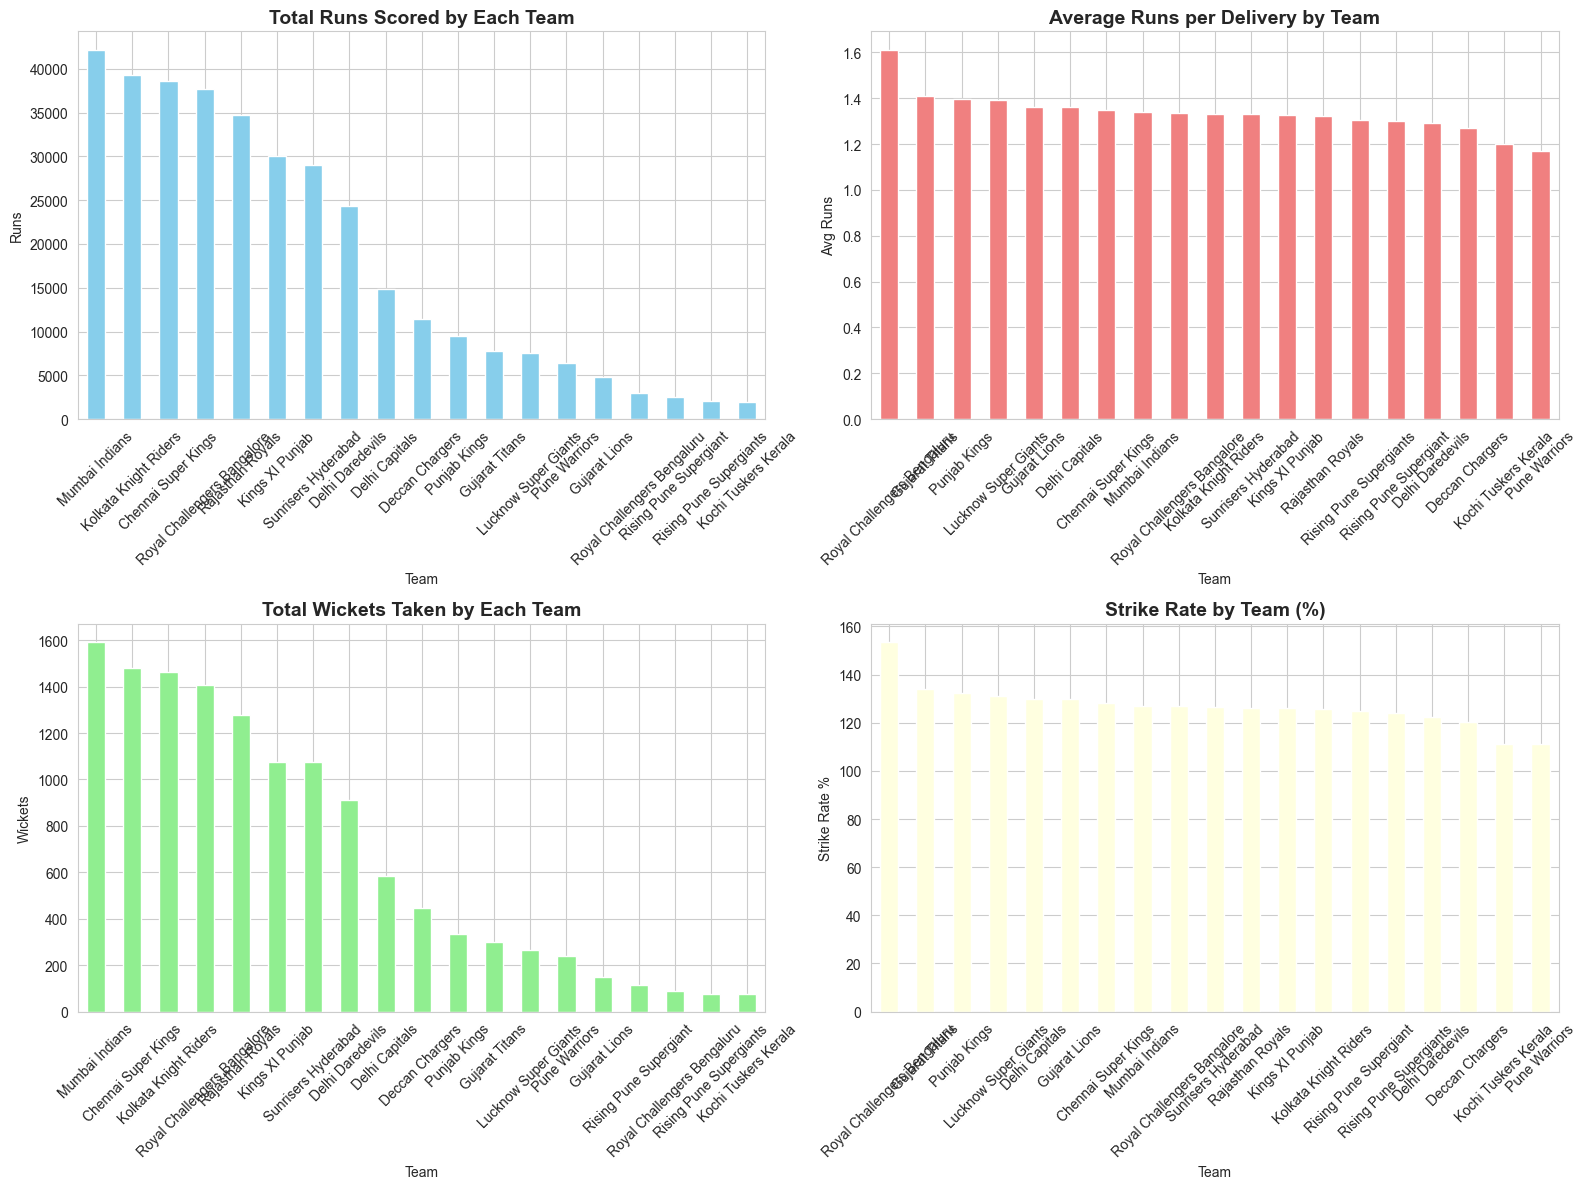

Visualizations created successfully!


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create subplots for venue-based insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total runs by batting team
team_runs.plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Total Runs Scored by Each Team', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Team')
axes[0, 0].set_ylabel('Runs')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Average runs per delivery
team_avg_runs.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Runs per Delivery by Team', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Team')
axes[0, 1].set_ylabel('Avg Runs')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Wickets taken by bowling team
team_wickets.plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Total Wickets Taken by Each Team', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Team')
axes[1, 0].set_ylabel('Wickets')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Strike rate comparison
team_strike_rate.plot(kind='bar', ax=axes[1, 1], color='lightyellow')
axes[1, 1].set_title('Strike Rate by Team (%)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Team')
axes[1, 1].set_ylabel('Strike Rate %')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

## Enhanced Venue Analysis (with Match Details)

In [31]:
# Load matches data
matches = pd.read_csv('../Data/matches.csv')
print("Matches Data Shape:", matches.shape)
print("\nMatches Columns:")
print(matches.columns.tolist())
print("\nFirst few matches:")
print(matches.head())

Matches Data Shape: (1095, 20)

Matches Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

First few matches:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                  

In [32]:
# Merge deliveries with match information using match_id and id
# Rename 'id' column in matches to 'match_id' for merging
matches_renamed = matches.rename(columns={'id': 'match_id'})

# Merge datasets
df_merged = df.merge(matches_renamed, on='match_id', how='left')

print("Merged Dataset Shape:", df_merged.shape)
print("\nVenue Information Available:")
print(f"Unique venues: {df_merged['venue'].nunique()}")
print(f"Venues: {df_merged['venue'].unique()[:10]}")
print("\nMerged data sample:")
print(df_merged[['match_id', 'batting_team', 'bowling_team', 'venue', 'total_runs', 'is_wicket']].head())

Merged Dataset Shape: (260920, 36)

Venue Information Available:
Unique venues: 58
Venues: <ArrowStringArray>
[                     'M Chinnaswamy Stadium',
 'Punjab Cricket Association Stadium, Mohali',
                           'Feroz Shah Kotla',
                           'Wankhede Stadium',
                               'Eden Gardens',
                     'Sawai Mansingh Stadium',
  'Rajiv Gandhi International Stadium, Uppal',
            'MA Chidambaram Stadium, Chepauk',
                 'Dr DY Patil Sports Academy',
                                   'Newlands']
Length: 10, dtype: str

Merged data sample:
   match_id           batting_team                 bowling_team  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
2    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
3    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
4    335982  Kolkata Knight Riders  Royal

In [33]:
## Venue-Specific Analysis

In [34]:
print("="*70)
print("VENUE-SPECIFIC ANALYSIS")
print("="*70)

# 1. Total runs scored at each venue
venue_runs = df_merged.groupby('venue')['total_runs'].sum().sort_values(ascending=False)
print("\n1. Total Runs Scored at Each Venue (Top 10):")
print(venue_runs.head(10))

# 2. Average runs per delivery by venue
venue_avg_runs = (df_merged.groupby('venue')['total_runs'].sum() / 
                  df_merged.groupby('venue').size()).sort_values(ascending=False)
print("\n2. Average Runs per Delivery by Venue (Top 10):")
print(venue_avg_runs.head(10))

# 3. Wickets at each venue
venue_wickets = df_merged[df_merged['is_wicket'] == 1].groupby('venue').size().sort_values(ascending=False)
print("\n3. Total Wickets at Each Venue (Top 10):")
print(venue_wickets.head(10))

# 4. Number of matches at each venue
venue_matches = df_merged.groupby('venue')['match_id'].nunique().sort_values(ascending=False)
print("\n4. Number of Matches at Each Venue (Top 10):")
print(venue_matches.head(10))

# 5. Venue characteristics
venue_stats = pd.DataFrame({
    'Matches': venue_matches,
    'Total_Runs': venue_runs,
    'Avg_Runs_Per_Delivery': venue_avg_runs,
    'Total_Wickets': venue_wickets
}).fillna(0).sort_values('Total_Runs', ascending=False)

print("\n5. Comprehensive Venue Statistics (Top 10):")
print(venue_stats.head(10))

VENUE-SPECIFIC ANALYSIS

1. Total Runs Scored at Each Venue (Top 10):
venue
Eden Gardens                                  23658
Wankhede Stadium                              23407
M Chinnaswamy Stadium                         20263
Feroz Shah Kotla                              18421
Wankhede Stadium, Mumbai                      15587
MA Chidambaram Stadium, Chepauk               15277
Rajiv Gandhi International Stadium, Uppal     14888
Dubai International Cricket Stadium           14450
Sawai Mansingh Stadium                        14264
Punjab Cricket Association Stadium, Mohali    10987
Name: total_runs, dtype: int64

2. Average Runs per Delivery by Venue (Top 10):
venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    1.600000
Eden Gardens, Kolkata                                                 1.577242
M Chinnaswamy Stadium, Bengaluru                                      1.554777
Himachal Pradesh Cricket Association Stadium, Dharamsala              1.542770
Pu

In [35]:
# 6. Team performance at different venues
print("\n6. Top 15 Team-Venue Combinations by Average Runs:")
team_venue_performance = df_merged.groupby(['batting_team', 'venue']).agg({
    'total_runs': ['sum', 'mean'],
    'match_id': 'nunique'
}).reset_index()

team_venue_performance.columns = ['Team', 'Venue', 'Total_Runs', 'Avg_Runs_Per_Delivery', 'Matches']
team_venue_performance = team_venue_performance[team_venue_performance['Matches'] >= 2].sort_values(
    'Avg_Runs_Per_Delivery', ascending=False
)
print(team_venue_performance.head(15))

# 7. Highest scoring matches at each venue
print("\n7. Highest Scoring Matches by Venue (Sample):")
highest_scoring = df_merged.groupby(['venue', 'match_id'])['total_runs'].sum().sort_values(ascending=False).head(10)
print(highest_scoring)


6. Top 15 Team-Venue Combinations by Average Runs:
                            Team  \
335                 Punjab Kings   
302               Mumbai Indians   
282               Mumbai Indians   
367             Rajasthan Royals   
476          Sunrisers Hyderabad   
463  Royal Challengers Bengaluru   
223        Kolkata Knight Riders   
359             Rajasthan Royals   
1            Chennai Super Kings   
21           Chennai Super Kings   
267               Mumbai Indians   
78                Delhi Capitals   
28           Chennai Super Kings   
446  Royal Challengers Bangalore   
147               Gujarat Titans   

                                                 Venue  Total_Runs  \
335                              Eden Gardens, Kolkata         441   
302  Rajiv Gandhi International Stadium, Uppal, Hyd...         438   
282                             Holkar Cricket Stadium         375   
367                              M.Chinnaswamy Stadium         258   
476                  

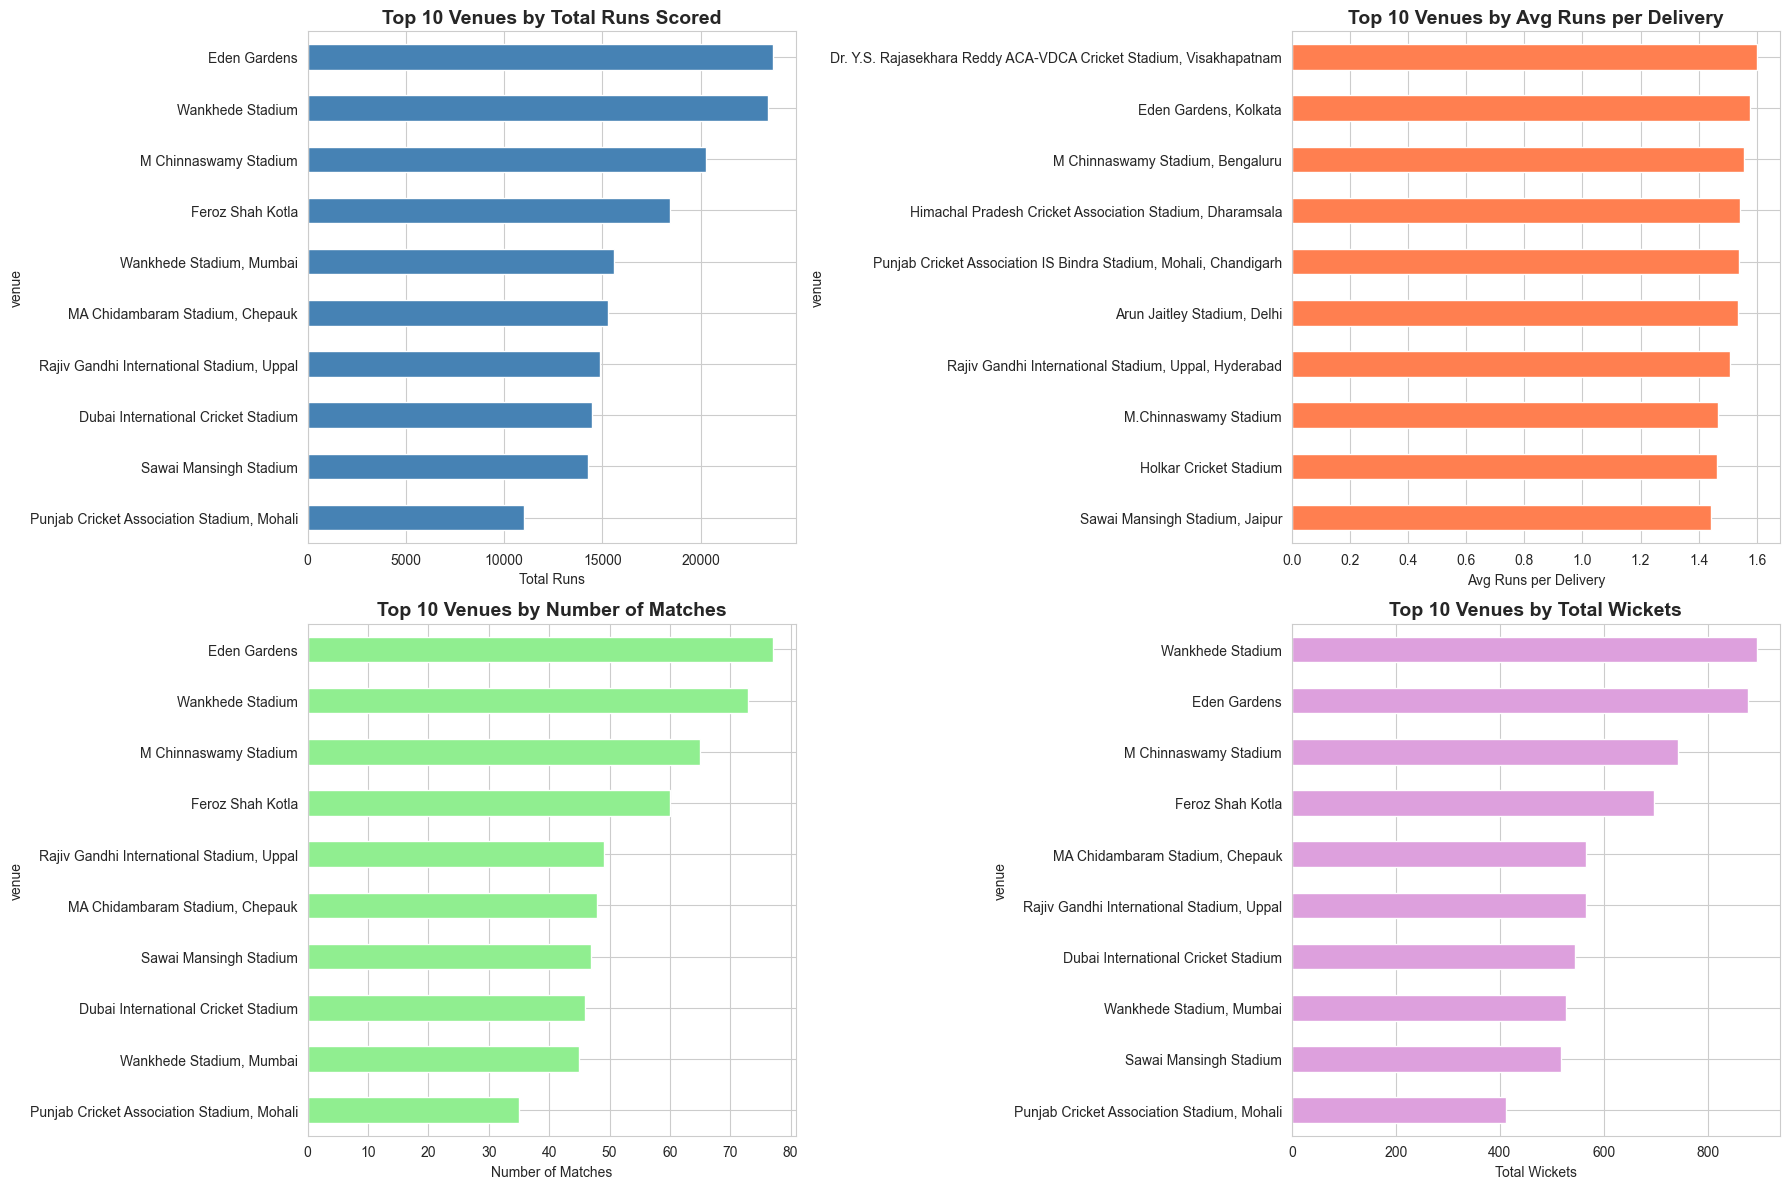

✓ Venue visualizations created successfully!


In [36]:
# Create comprehensive venue visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Top 10 venues by total runs
top_venues_runs = venue_runs.head(10)
top_venues_runs.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 10 Venues by Total Runs Scored', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Runs')
axes[0, 0].invert_yaxis()

# Plot 2: Top 10 venues by average runs per delivery
top_venues_avg = venue_avg_runs.head(10)
top_venues_avg.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Top 10 Venues by Avg Runs per Delivery', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Avg Runs per Delivery')
axes[0, 1].invert_yaxis()

# Plot 3: Top 10 venues by matches hosted
top_venues_matches = venue_matches.head(10)
top_venues_matches.plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Top 10 Venues by Number of Matches', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Matches')
axes[1, 0].invert_yaxis()

# Plot 4: Top 10 venues by total wickets
top_venues_wickets = venue_wickets.head(10)
top_venues_wickets.plot(kind='barh', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Top 10 Venues by Total Wickets', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Wickets')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Venue visualizations created successfully!")

In [37]:
print("\n" + "="*70)
print("KEY VENUE-BASED INSIGHTS")
print("="*70)

top_venue = venue_runs.idxmax()
print(f"\n✓ Most Runs Scored Venue: {top_venue} ({int(venue_runs.max())} runs)")

highest_avg_venue = venue_avg_runs.idxmax()
print(f"✓ Highest Scoring Venue (per delivery): {highest_avg_venue} ({venue_avg_runs.max():.3f} avg runs)")

most_matches_venue = venue_matches.idxmax()
print(f"✓ Most Matches Hosted: {most_matches_venue} ({int(venue_matches.max())} matches)")

most_wickets_venue = venue_wickets.idxmax()
print(f"✓ Most Wickets at Venue: {most_wickets_venue} ({int(venue_wickets.max())} wickets)")

best_team_venue = team_venue_performance.iloc[0]
print(f"\n✓ Best Team-Venue Combination:")
print(f"  Team: {best_team_venue['Team']}")
print(f"  Venue: {best_team_venue['Venue']}")
print(f"  Avg Runs/Delivery: {best_team_venue['Avg_Runs_Per_Delivery']:.3f}")
print(f"  Matches: {int(best_team_venue['Matches'])}")

# Pitch characteristics
print(f"\n✓ Venue Characteristics:")
high_scoring_venues = venue_avg_runs[venue_avg_runs > venue_avg_runs.mean()].index.tolist()[:5]
low_scoring_venues = venue_avg_runs[venue_avg_runs < venue_avg_runs.mean()].index.tolist()[:5]
print(f"  High-Scoring Venues (Batting-Friendly):")
for v in high_scoring_venues:
    print(f"    - {v}: {venue_avg_runs[v]:.3f} runs/delivery")
print(f"\n  Low-Scoring Venues (Bowling-Friendly):")
for v in low_scoring_venues:
    print(f"    - {v}: {venue_avg_runs[v]:.3f} runs/delivery")

print("\n" + "="*70)


KEY VENUE-BASED INSIGHTS

✓ Most Runs Scored Venue: Eden Gardens (23658 runs)
✓ Highest Scoring Venue (per delivery): Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam (1.600 avg runs)
✓ Most Matches Hosted: Eden Gardens (77 matches)
✓ Most Wickets at Venue: Wankhede Stadium (894 wickets)

✓ Best Team-Venue Combination:
  Team: Punjab Kings
  Venue: Eden Gardens, Kolkata
  Avg Runs/Delivery: 1.822
  Matches: 2

✓ Venue Characteristics:
  High-Scoring Venues (Batting-Friendly):
    - Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam: 1.600 runs/delivery
    - Eden Gardens, Kolkata: 1.577 runs/delivery
    - M Chinnaswamy Stadium, Bengaluru: 1.555 runs/delivery
    - Himachal Pradesh Cricket Association Stadium, Dharamsala: 1.543 runs/delivery
    - Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh: 1.538 runs/delivery

  Low-Scoring Venues (Bowling-Friendly):
    - Wankhede Stadium: 1.331 runs/delivery
    - Punjab Cricket Association St

## 1. Player Analysis - Top Batsmen & Bowlers

In [38]:
print("="*70)
print("TOP BATSMEN ANALYSIS")
print("="*70)

# Batsmen statistics
batsmen_stats = df_merged.groupby('batter').agg({
    'batsman_runs': ['sum', 'count', 'mean'],
    'is_wicket': 'sum',
    'match_id': 'nunique'
}).reset_index()
batsmen_stats.columns = ['Batter', 'Runs', 'Deliveries', 'Avg_Per_Delivery', 'Dismissals', 'Matches']
batsmen_stats['Strike_Rate'] = (batsmen_stats['Runs'] / batsmen_stats['Deliveries'] * 100).round(2)
batsmen_stats['Avg_Per_Match'] = (batsmen_stats['Runs'] / batsmen_stats['Matches']).round(2)
batsmen_stats = batsmen_stats[batsmen_stats['Deliveries'] >= 10].sort_values('Runs', ascending=False)

print("\n1. Top 20 Batsmen by Total Runs:")
print(batsmen_stats[['Batter', 'Runs', 'Deliveries', 'Strike_Rate', 'Matches']].head(20))

print("\n2. Top 20 Batsmen by Strike Rate:")
print(batsmen_stats.nlargest(20, 'Strike_Rate')[['Batter', 'Strike_Rate', 'Runs', 'Matches']])

# Top bowlers
print("\n" + "="*70)
print("TOP BOWLERS ANALYSIS")
print("="*70)

bowler_stats = df_merged.groupby('bowler').agg({
    'is_wicket': 'sum',
    'total_runs': 'sum',
    'match_id': ['count', 'nunique']
}).reset_index()
bowler_stats.columns = ['Bowler', 'Wickets', 'Runs_Given', 'Deliveries', 'Matches']
bowler_stats['Economy'] = (bowler_stats['Runs_Given'] / (bowler_stats['Deliveries']/6)).round(2)
bowler_stats['Wickets_Per_Match'] = (bowler_stats['Wickets'] / bowler_stats['Matches']).round(2)
bowler_stats = bowler_stats[bowler_stats['Deliveries'] >= 10].sort_values('Wickets', ascending=False)

print("\n3. Top 20 Bowlers by Wickets:")
print(bowler_stats[['Bowler', 'Wickets', 'Runs_Given', 'Economy', 'Matches']].head(20))

print("\n4. Top 20 Bowlers by Economy Rate:")
print(bowler_stats.nsmallest(20, 'Economy')[['Bowler', 'Economy', 'Wickets', 'Matches']])

TOP BATSMEN ANALYSIS

1. Top 20 Batsmen by Total Runs:
             Batter  Runs  Deliveries  Strike_Rate  Matches
631         V Kohli  8014        6236       128.51      244
512        S Dhawan  6769        5483       123.45      221
477       RG Sharma  6630        5183       127.92      251
147       DA Warner  6567        4849       135.43      184
546        SK Raina  5536        4177       132.54      200
374        MS Dhoni  5243        3947       132.84      228
30   AB de Villiers  5181        3487       148.58      170
124        CH Gayle  4997        3516       142.12      141
501      RV Uthappa  4954        3927       126.15      197
282      KD Karthik  4843        3687       131.35      233
289        KL Rahul  4689        3578       131.05      122
50        AM Rahane  4642        3858       120.32      171
188    F du Plessis  4571        3435       133.07      138
572       SV Samson  4419        3270       135.14      162
64        AT Rayudu  4348        3490       1

## 2. Team Performance - Wins, Statistics & Head-to-Head

In [39]:
print("="*70)
print("TEAM PERFORMANCE ANALYSIS")
print("="*70)

# Team wins analysis
team_wins = matches_renamed.groupby('winner').size().sort_values(ascending=False)
print("\n1. Team Win Counts:")
print(team_wins)

# Team match statistics
team_stats = df_merged.groupby('batting_team').agg({
    'total_runs': ['sum', 'mean'],
    'match_id': 'nunique',
    'is_wicket': 'sum'
}).reset_index()
team_stats.columns = ['Team', 'Total_Runs', 'Avg_Runs_Per_Delivery', 'Matches', 'Total_Wickets_Lost']
team_stats['Runs_Per_Match'] = (team_stats['Total_Runs'] / team_stats['Matches']).round(2)
team_stats['Win_Rate'] = team_stats['Team'].map(lambda x: team_wins.get(x, 0) / team_stats[team_stats['Team']==x]['Matches'].values[0] * 100 if team_stats[team_stats['Team']==x]['Matches'].values[0] > 0 else 0).round(2)
team_stats = team_stats.sort_values('Runs_Per_Match', ascending=False)

print("\n2. Team Statistics (Sorted by Avg Runs/Match):")
print(team_stats[['Team', 'Matches', 'Runs_Per_Match', 'Avg_Runs_Per_Delivery', 'Total_Wickets_Lost']])

print("\n3. Team Win Rates:")
win_rates = team_stats[['Team', 'Win_Rate']].sort_values('Win_Rate', ascending=False)
print(win_rates)

# Head-to-head records
print("\n4. Top 10 Team Head-to-Head Matchups:")
h2h = matches_renamed.groupby(['team1', 'team2', 'winner']).size().reset_index(name='count')
h2h = h2h.sort_values('count', ascending=False)
print(h2h.head(10))

TEAM PERFORMANCE ANALYSIS

1. Team Win Counts:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Punjab Kings                    24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
dtype: int64

2. Team Statistics (Sorted by Avg Runs/Match):
                           Team  Matches  Runs_Per_Match  \
17  Royal Challengers Bengaluru       15          195.33   
5                Gujarat Titans       45          172.38   
9          Lucknow Super Giants       44

## 3. Innings Breakdown - Powerplay, Middle & Death Overs

In [40]:
print("="*70)
print("INNINGS BREAKDOWN ANALYSIS")
print("="*70)

# Define phases: Powerplay (overs 0-5), Middle (6-15), Death (16-19)
def get_phase(over):
    if over < 6:
        return 'Powerplay'
    elif over < 16:
        return 'Middle'
    else:
        return 'Death'

df_merged['phase'] = df_merged['over'].apply(get_phase)

# Phase-wise statistics
phase_stats = df_merged.groupby('phase').agg({
    'total_runs': ['sum', 'count', 'mean'],
    'is_wicket': 'sum'
}).reset_index()
phase_stats.columns = ['Phase', 'Total_Runs', 'Deliveries', 'Avg_Per_Delivery', 'Wickets']
phase_stats['Runs_Per_Over'] = (phase_stats['Total_Runs'] / (phase_stats['Deliveries'] / 6)).round(2)

print("\n1. Phase-wise Performance Summary:")
print(phase_stats)

# Batting team performance by phase
print("\n2. Top 5 Batting Teams in Each Phase:")
for phase in ['Powerplay', 'Middle', 'Death']:
    phase_data = df_merged[df_merged['phase'] == phase].groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
    print(f"\n{phase}:")
    print(phase_data.head(5))

# Wickets in each phase
print("\n3. Wicket Distribution by Phase:")
wicket_phase = df_merged[df_merged['is_wicket'] == 1].groupby('phase').size()
print(wicket_phase)

INNINGS BREAKDOWN ANALYSIS

1. Phase-wise Performance Summary:
       Phase  Total_Runs  Deliveries  Avg_Per_Delivery  Wickets  Runs_Per_Over
0      Death       75412       46584          1.618839     4052           9.71
1     Middle      169127      132431          1.277095     5735           7.66
2  Powerplay      103217       81905          1.260204     3163           7.56

2. Top 5 Batting Teams in Each Phase:

Powerplay:
batting_team
Mumbai Indians                 12225
Kolkata Knight Riders          11941
Chennai Super Kings            10991
Royal Challengers Bangalore    10919
Rajasthan Royals               10226
Name: total_runs, dtype: int64

Middle:
batting_team
Mumbai Indians                 20353
Kolkata Knight Riders          19337
Chennai Super Kings            18577
Royal Challengers Bangalore    18356
Rajasthan Royals               17240
Name: total_runs, dtype: int64

Death:
batting_team
Mumbai Indians                 9598
Chennai Super Kings            9061
Royal Chal

## 4. Dismissal Patterns - Modes, Players & Bowling Strategies

In [41]:
print("="*70)
print("DISMISSAL PATTERNS ANALYSIS")
print("="*70)

# Dismissal kind statistics
dismissals_data = df_merged[df_merged['is_wicket'] == 1]
print("\n1. Dismissal Methods Distribution:")
dismissal_kinds = dismissals_data['dismissal_kind'].value_counts()
print(dismissal_kinds)

# Most vulnerable batsmen (most dismissals)
print("\n2. Most Dismissed Batsmen (Top 15):")
vulnerable_batsmen = dismissals_data['player_dismissed'].value_counts().head(15)
print(vulnerable_batsmen)

# Most successful bowlers (by dismissals)
print("\n3. Most Successful Bowlers (Top 15):")
successful_bowlers = dismissals_data['bowler'].value_counts().head(15)
print(successful_bowlers)

# Dismissal kind by bowler (top bowlers' strategies)
print("\n4. Top 5 Bowlers' Dismissal Strategies:")
for bowler in successful_bowlers.head(5).index:
    bowler_dismissals = dismissals_data[dismissals_data['bowler'] == bowler]['dismissal_kind'].value_counts()
    print(f"\n{bowler}:")
    print(bowler_dismissals)

# Fielders involved in dismissals
print("\n5. Top Fielders (Catches/Stumpings):")
fielder_stats = dismissals_data[dismissals_data['fielder'] != 'None']['fielder'].value_counts().head(10)
print(fielder_stats)

DISMISSAL PATTERNS ANALYSIS

1. Dismissal Methods Distribution:
dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

2. Most Dismissed Batsmen (Top 15):
player_dismissed
RG Sharma         223
V Kohli           207
S Dhawan          193
KD Karthik        184
RV Uthappa        180
SK Raina          171
DA Warner         164
AT Rayudu         155
AM Rahane         154
SV Samson         144
G Gambhir         136
MS Dhoni          134
MK Pandey         133
AB de Villiers    130
F du Plessis      127
Name: count, dtype: int64

3. Most Successful Bowlers (Top 15):
bowler
YS Chahal          213
DJ Bravo           207
PP Chawla          201
SP Narine          200
R Ashwin           198
B Kumar            195
SL

## 5. Statistical Summary & Comprehensive Dashboards

In [42]:
plt.tight_layout()
plt.savefig('../Output_Files/ipl_comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
print("\n✓ Comprehensive dashboard saved as 'ipl_comprehensive_dashboard.png'")
plt.show()


✓ Comprehensive dashboard saved as 'ipl_comprehensive_dashboard.png'


<Figure size 1400x1000 with 0 Axes>

## 6. Data Exports

In [43]:
print("="*70)
print("EXPORTING ALL ANALYSIS DATA TO CSV FILES")
print("="*70)

# Export all analysis data to CSV files
exports = {
    '../Output_Files/batsmen_stats.csv': batsmen_stats[['Batter', 'Runs', 'Matches', 'Deliveries', 'Strike_Rate', 'Avg_Per_Match']],
    '../Output_Files/bowler_stats.csv': bowler_stats[['Bowler', 'Wickets', 'Runs_Given', 'Deliveries', 'Economy', 'Matches']],
    '../Output_Files/team_stats.csv': team_stats[['Team', 'Matches', 'Runs_Per_Match', 'Avg_Runs_Per_Delivery', 'Total_Wickets_Lost']],
    '../Output_Files/phase_stats.csv': phase_stats,
    '../Output_Files/dismissal_summary.csv': pd.DataFrame({
        'Dismissal_Kind': dismissal_kinds.index,
        'Count': dismissal_kinds.values
    })
}

for filepath, data in exports.items():
    data.to_csv(filepath, index=False)
    filename = filepath.split('/')[-1]
    print(f"[OK] Exported: {filename} ({len(data)} records)")

print("\n" + "="*70)
print("ALL ANALYSES COMPLETED SUCCESSFULLY!")
print("="*70)
print(f"\nFiles Exported: {len(exports)}")
print("\nFinal Summary Statistics:")
print(f"  • Total Deliveries Analyzed: {len(df_merged):,}")
print(f"  • Total Matches: {df_merged['match_id'].nunique()}")
print(f"  • Total Teams: {df_merged['batting_team'].nunique()}")
print(f"  • Total Batsmen: {df_merged['batter'].nunique()}")
print(f"  • Total Bowlers: {df_merged['bowler'].nunique()}")
print(f"  • Total Venues: {df_merged['venue'].nunique()}")
print(f"  • Total Dismissals: {df_merged['is_wicket'].sum()}")
print(f"  • Overall Strike Rate: {(df_merged['total_runs'].sum() / len(df_merged) * 100):.2f}%")
print("\n[COMPLETE] IPL Analysis Pipeline Complete!")

EXPORTING ALL ANALYSIS DATA TO CSV FILES
[OK] Exported: batsmen_stats.csv (564 records)
[OK] Exported: bowler_stats.csv (505 records)
[OK] Exported: team_stats.csv (19 records)
[OK] Exported: phase_stats.csv (3 records)
[OK] Exported: dismissal_summary.csv (10 records)

ALL ANALYSES COMPLETED SUCCESSFULLY!

Files Exported: 5

Final Summary Statistics:
  • Total Deliveries Analyzed: 260,920
  • Total Matches: 1095
  • Total Teams: 19
  • Total Batsmen: 673
  • Total Bowlers: 530
  • Total Venues: 58
  • Total Dismissals: 12950
  • Overall Strike Rate: 133.28%

[COMPLETE] IPL Analysis Pipeline Complete!
